## Root Cause Analysis: Why Are Some Routes Underperforming?

### Business Context

In the previous analysis, several routes were identified as consistently unprofitable, with a high percentage of trips generating losses. While this highlights where value is being lost, it does not explain why these routes are underperforming.

Understanding the drivers behind poor performance is critical for making effective decisions. Without identifying the root causes, actions such as eliminating or optimizing routes may not address the underlying issues.

---

### Objective

The objective of this analysis is to investigate whether operational inefficiencies contribute to route underperformance.

Specifically, we aim to determine if unprofitable routes differ from high-performing ones in terms of fuel efficiency and operational time.

---

### Approach

To achieve this, routes will be grouped based on their performance category (high-performing vs unprofitable), and key operational metrics will be compared across groups.

The analysis will focus on:

- Fuel efficiency (fuel consumption per distance, average MPG)  
- Trip duration and idle time  

By comparing these metrics, we aim to identify whether inefficiencies in operations help explain the differences in profitability across routes.

# SET UP: Importing all libraries and databases to analyse

In [1]:
#Data Handling
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

/kaggle/input/notebooks/danigutirrez/logoperations-performance-profitability-analysis/__results__.html
/kaggle/input/notebooks/danigutirrez/logoperations-performance-profitability-analysis/__notebook__.ipynb
/kaggle/input/notebooks/danigutirrez/logoperations-performance-profitability-analysis/__output__.json
/kaggle/input/notebooks/danigutirrez/logoperations-performance-profitability-analysis/custom.css
/kaggle/input/notebooks/danigutirrez/logoperations-performance-profitability-analysis/__results___files/__results___15_0.png
/kaggle/input/notebooks/danigutirrez/logoperations-performance-profitability-analysis/__results___files/__results___19_0.png
/kaggle/input/notebooks/danigutirrez/logoperations-performance-profitability-analysis/__results___files/__results___12_0.png
/kaggle/input/notebooks/danigutirrez/logoperations-performance-profitability-analysis/__results___files/__results___29_0.png
/kaggle/input/datasets/yogape/logistics-operations-database/routes.csv
/kaggle/input/datasets

In [2]:
## Import all CSV 
base_path = "/kaggle/input/datasets/yogape/logistics-operations-database/"
loads = pd.read_csv(base_path + "loads.csv")
routes = pd.read_csv(base_path + "routes.csv")
trips = pd.read_csv(base_path + "trips.csv")
fuel = pd.read_csv(base_path + "fuel_purchases.csv")

In [3]:
loads_cols = ["load_id", "route_id", "revenue", "fuel_surcharge", "accessorial_charges"]
trips_cols = ["trip_id", "load_id", "actual_distance_miles", "fuel_gallons_used", "actual_duration_hours", "idle_time_hours"]
routes_cols = ["route_id", "origin_city", "destination_city"]

loads_and_trips = loads[loads_cols].merge(trips[trips_cols], on="load_id", how="inner")
base_table = loads_and_trips.merge(routes[routes_cols], on="route_id", how="inner")

print(base_table.columns)

Index(['load_id', 'route_id', 'revenue', 'fuel_surcharge',
       'accessorial_charges', 'trip_id', 'actual_distance_miles',
       'fuel_gallons_used', 'actual_duration_hours', 'idle_time_hours',
       'origin_city', 'destination_city'],
      dtype='object')


In [4]:
# Aggregate fuel costs per trip to align with trip-level analysis
fuel_cost_per_trip = fuel.groupby("trip_id").agg({
    "total_cost": "sum"
}).reset_index()

fuel_cost_per_trip = fuel_cost_per_trip.rename(columns={
    "total_cost": "fuel_cost"
})

base_table = base_table.merge(fuel_cost_per_trip, on="trip_id", how="inner")

In [5]:
# Aggregate new columns to create the summaries
base_table["total_revenue"] = (
    base_table["revenue"] 
    + base_table["fuel_surcharge"] 
    + base_table["accessorial_charges"]
)

base_table["fuel_per_mile"] = (
    base_table["fuel_gallons_used"] 
    / base_table["actual_distance_miles"]
)

base_table["idle_ratio"] = (
    base_table["idle_time_hours"] 
    / base_table["actual_duration_hours"]
)
# Calculate profit as revenue - fuel costs since we don't have more costs.
base_table["profit"] = base_table["total_revenue"] - base_table['fuel_cost']
base_table['profitability'] = base_table['profit']<0

In [6]:
#  Group by Route
route_summary = base_table.groupby(by='route_id').agg({
    "profit": 'mean',
    'profitability':'mean',
    'fuel_per_mile' : 'mean',
    'actual_duration_hours': 'mean',
    'trip_id':'count'
    })

route_summary = route_summary.rename(columns={
    "profit": "avg_profit",
    'profitability':'pct_unprofitable',
    'fuel_per_mile' : 'avg_fuel_per_mile',
    'actual_duration_hours': 'avg_duration',
    'trip_id':'total_trips'})

route_summary['pct_unprofitable'] = route_summary['pct_unprofitable'] *100

route_summary= route_summary.sort_values('pct_unprofitable', ascending = False)

Unprofitable routes are not driven by fuel inefficiency, but by profit. 
Shorter routes generate significantly lower revenue per trip, while maintaining similar operational costs, leading to structurally negative margins.

To check this hipothesis we will create a new variable, called revenue per hour and plot it against pct_unprofitable.

In [7]:
route_summary['profit_per_hour'] = route_summary['avg_profit'] /route_summary['avg_duration']

print(route_summary[['avg_profit','profit_per_hour']])

           avg_profit  profit_per_hour
route_id                              
RTE00010 -1000.748462      -606.958084
RTE00015  -949.438298      -575.808831
RTE00033  -720.136257      -240.456915
RTE00036  -389.394173       -82.742509
RTE00047  -110.320007       -12.901148
RTE00011  -112.906603       -11.486024
RTE00022    89.768019         8.929230
RTE00058    94.915625        10.137286
RTE00001   140.202541        11.517357
RTE00013   121.275138        10.019953
RTE00045   337.464978        31.495856
RTE00050   378.467618        29.454873
RTE00031   419.943758        36.365949
RTE00052   378.734596        26.277476
RTE00002   435.249312        34.688559
RTE00006   456.447957        37.592283
RTE00018   451.474247        37.416238
RTE00009   685.343533        43.310709
RTE00049   883.301408        68.264767
RTE00053   856.968952        61.104175
RTE00008   934.492752        67.965920
RTE00017  1229.814853        60.542128
RTE00035  1277.407034        57.737707
RTE00057  1380.483273    

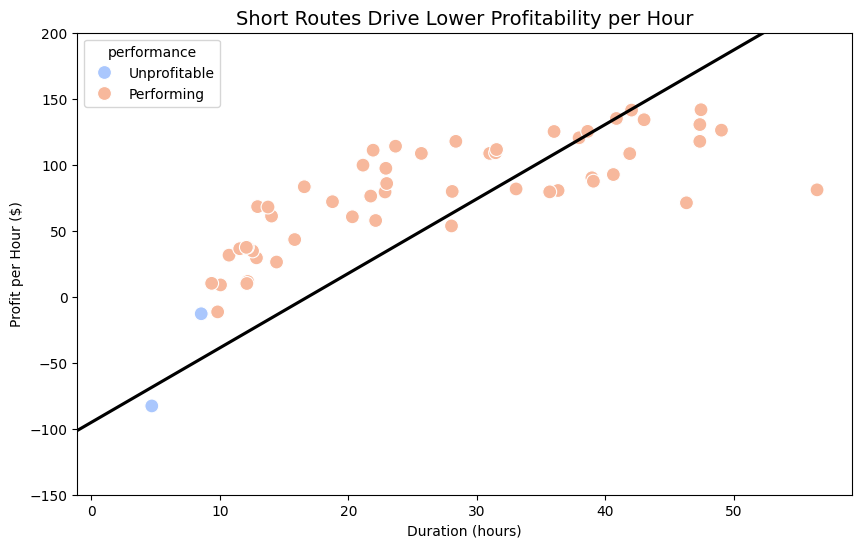

In [8]:
route_summary["performance"] = route_summary["pct_unprofitable"].apply(
    lambda x: "Unprofitable" if x > 50 else "Performing"
)
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=route_summary,
    x="avg_duration",
    y="profit_per_hour",
    hue="performance",
    palette="coolwarm",
    s=100,
)
sns.regplot(
    data=route_summary,
    x="avg_duration",
    y="profit_per_hour",
    scatter=False,
    color="black",
    truncate=False,
    ci=None,
)

plt.title("Short Routes Drive Lower Profitability per Hour", fontsize=14)
plt.xlabel("Duration (hours)")
plt.ylabel("Profit per Hour ($)")
plt.ylim(-150, 200) #Deleting the three outliers that shifts the charts
plt.show()

Short-duration routes consistently show lower or negative profitability per hour, while longer routes generate significantly higher returns.

This indicates that underperformance is driven by poor time-based unit economics rather than operational inefficiencies such as fuel consumption.

## Root Cause Analysis: Why Are Some Routes Underperforming?

While most routes are profitable, a subset consistently underperforms. Understanding the root causes behind these routes is critical to improving overall network profitability.

### Key Findings

- Profitability is highly uneven across routes, with a small number of routes generating consistent losses.
- Fuel efficiency is consistent across routes, indicating that operational performance is not the main driver of underperformance.
- Route duration shows a strong positive relationship with profitability per hour.
- Short-duration routes consistently generate lower or negative returns.

### Core Insight

Underperforming routes are not driven by operational inefficiencies, but by poor time-based unit economics.

Short routes generate insufficient revenue per trip while maintaining similar cost structures, resulting in structurally negative profitability.

### Visual Insight

The relationship between route duration and profitability per hour shows a clear pattern: longer routes generate significantly higher returns, while short routes cluster around low or negative profitability.

### Recommendations

- Re-evaluate pricing strategies for short-duration routes to better reflect operational costs.
- Consider consolidating or eliminating structurally unprofitable routes.
- Prioritize growth on longer routes with proven profitability per hour.